Грахович 955-М. Вариант 18

#**QR-code ссылка на репозиторий в [Github](https://github.com/kubenet/ML_course)**

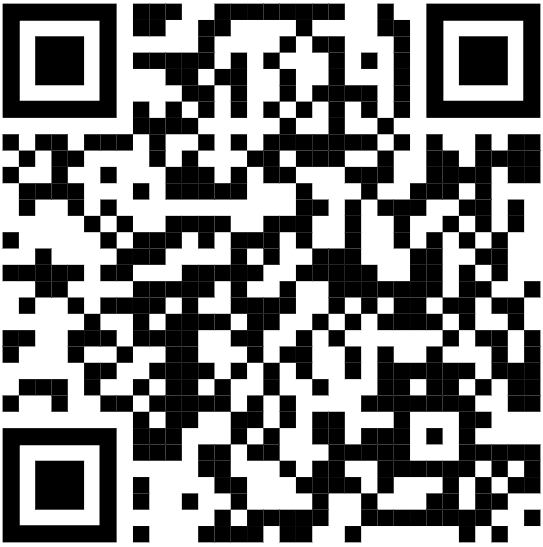

# Практическая работа №4: Регуляризация, Переобучение и Отбор Признаков

**Дисциплина:** Машинное обучение (Machine Learning)  
**Уровень:** Практикум / Базовый  
**Автор:** Осинцев Артем Викторович

---

---

# Практика №4: Регуляризация, Переобучение и Отбор Признаков

## 🎯 Цели занятия
1.  Изучить эффект переобучения на примере полиномиальной регрессии.
2.  Понять разницу между $L_1$ (Lasso) и $L_2$ (Ridge) регуляризацией.
3.  Научиться подбирать гиперпараметры через кросс-валидацию.
4.  Проанализировать устойчивость отбора признаков на реальных данных.

---

## 📚 Теоретический блок 1:Bias-Variance Tradeoff и Полиномиальная регрессия

**Концепция:**
Модель машинного обучения стремится минимизировать ошибку обобщения. Она складывается из:
$$ \text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error} $$

*   **Низкая степень полинома:** Высокое смещение (Bias), модель слишком простая (недообучение).
*   **Высокая степень полинома:** Высокая дисперсия (Variance), модель подстраивается под шум (переобучение).

**Регуляризация:**
Чтобы контролировать сложность модели, мы добавляем штрафной член к функции потерь (Loss Function):
*   **Ridge ($L_2$):** $J(\theta) = \text{MSE}(\theta) + \alpha \sum_{j=1}^{n} \theta_j^2$. Сжимает веса, но не обнуляет их.
*   **Lasso ($L_1$):** $J(\theta) = \text{MSE}(\theta) + \alpha \sum_{j=1}^{n} |\theta_j|$. Может обнулять веса, выполняя отбор признаков.

> ⚠️ **Важно:** Перед применением Ridge и Lasso данные необходимо масштабировать (Standardization), иначе штраф будет применяться неравномерно к признакам с разными масштабами.




















---

## 💻 Практический блок 1: Генерация данных и Кривые обучения






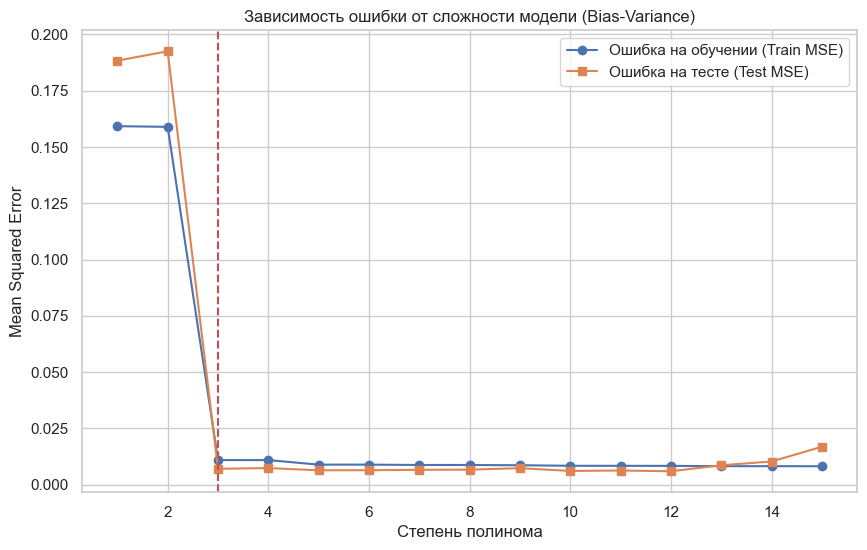

In [1]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes

# Настройка стилей для графиков
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Генерация синтетических данных
np.random.seed(42)
n_samples = 100
X_syn = np.sort(np.random.uniform(-3, 3, n_samples)).reshape(-1, 1)
# Истинная зависимость: синусоида + шум
y_syn = np.sin(X_syn.ravel()) + np.random.normal(0, 0.1, n_samples)

# Разделение на train и test
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_syn, y_syn, test_size=0.3, random_state=42
)
# Разделение данных на обучающую (70%) и тестовую (30%) выборки. Тестовая выборка имитирует новые, невиданные данные для оценки обобщающей способности модели.

# 2. Построение кривых обучения для степеней 1-15
degrees = range(1, 16)
train_errors, test_errors = [], []


# Для каждой степени полинома (от 1 до 15):
# Создаются полиномиальные признаки
# Данные масштабируются (критично для сравнения с Ridge/Lasso)
# Обучается линейная регрессия
# Вычисляется MSE на train и test
for d in degrees:
    # Пайплайн: Полином -> Масштабирование -> Линейная регрессия
    # Примечание: Для обычной регрессии масштабирование полиномов не всегда критично,
    # но для сравнения с Ridge/Lasso введем его сразу для единообразия.
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lin_reg', LinearRegression())
    ])

    model.fit(X_train_syn, y_train_syn)

    y_train_pred = model.predict(X_train_syn)
    y_test_pred = model.predict(X_test_syn)

    train_errors.append(mean_squared_error(y_train_syn, y_train_pred))
    test_errors.append(mean_squared_error(y_test_syn, y_test_pred))

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, label='Ошибка на обучении (Train MSE)', marker='o')
plt.plot(degrees, test_errors, label='Ошибка на тесте (Test MSE)', marker='s')
plt.xlabel('Степень полинома')
plt.ylabel('Mean Squared Error')
plt.title('Зависимость ошибки от сложности модели (Bias-Variance)')
plt.legend()
plt.axvline(x=3, color='r', linestyle='--', label='Примерная оптимальная сложность')
plt.show()

###График: Ошибка на обучении vs Ошибка на тесте

###Визуальная интерпретация:
- Синяя линия (Train): Монотонно убывает, стремится к нулю
- Оранжевая линия (Test): U-образная кривая с минимумом при степени 3-5
- Разрыв (Gap): Чем больше разрыв между линиями, тем сильнее переобучение

###Как мы это используем
- Выбор оптимальной сложности модели: Находим степень полинома, где ошибка на тесте минимальна.
- Диагностика переобучения: Если Train MSE << Test MSE → модель запоминает шум.
- Обоснование регуляризации: Показываем, что простое увеличение сложности ухудшает обобщение.

"Эксперимент демонстрирует классический `Bias-Variance Tradeoff`: увеличение сложности модели снижает смещение, но увеличивает дисперсию, что приводит к росту ошибки обобщения после определённого порога."

### 🧠 Комментарий:
Обратите внимание на график. Ошибка на обучении монотонно убывает (модель запоминает данные). Ошибка на тесте сначала падает, а затем растет после определенной степени (обычно 3-5 для синуса). Это точка **переобучения**.

##Выводы:

- Сложность ≠ Качество - модель 15-й степени хуже модели 4-й степени на новых данных
- Нужен баланс - оптимальная степень полинома соответствует минимуму Test MSE
- Train MSE ненадёжен - нельзя оценивать модель только по ошибке на обучении
- Регуляризация необходима - для высоких степеней нужен механизм контроля сложности

---

## 📚 Теоретический блок 2: Влияние параметра $\alpha$ на коэффициенты

При увеличении $\alpha$ (силы регуляризации):
1.  **Ridge:** Коэффициенты стремятся к нулю асимптотически.
2.  **Lasso:** Коэффициенты становятся равными нулю точно (спарсность). Это позволяет исключить неинформативные признаки.

---

## 💻 Практический блок 2: Пути регуляризации (Coefficient Paths)

Для демонстрации возьмем высокую степень полинома (например, 15), чтобы создать много признаков и увидеть, как регуляризация их "гасит".


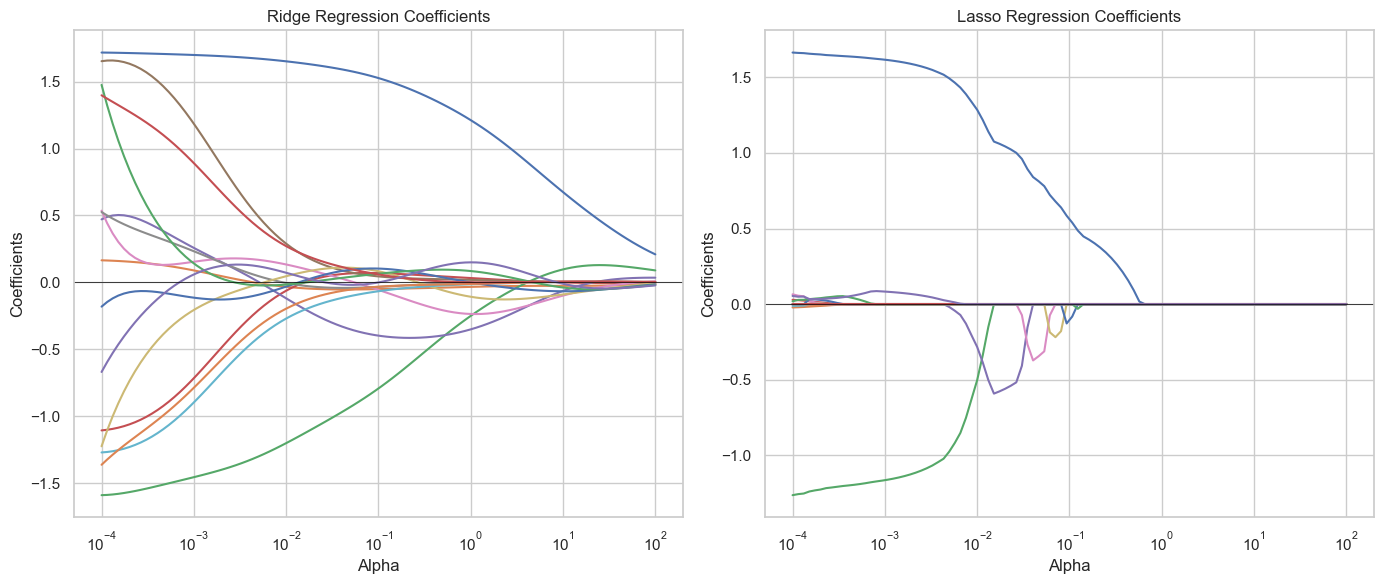

In [2]:
# Создаем полиномиальные признаки высокой степени
poly = PolynomialFeatures(degree=15, include_bias=False)
# Получаем 15 признаков из 1 исходного: x, x², x³, ..., x¹⁵

X_train_poly = poly.fit_transform(X_train_syn)
X_test_poly = poly.transform(X_test_syn)

# Масштабируем признаки (Критично для регуляризации!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

"""
Почему масштабирование обязательно:
- Ridge/Lasso штрафуют величину коэффициентов
- Без масштабирования признак с большим диапазоном значений получит меньший коэффициент и меньший штраф
- Это приведёт к несправедливой регуляризации
"""

# Диапазон альфа (логарифмическая шкала)
alphas = np.logspace(-4, 2, 100)

ridge_coefs = []
lasso_coefs = []

for a in alphas:
    # Ridge
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train_syn)
    ridge_coefs.append(ridge.coef_)

    # Lasso
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train_syn)
    lasso_coefs.append(lasso.coef_)

# Визуализация путей коэффициентов
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Ridge
ax[0].plot(alphas, ridge_coefs)
ax[0].set_xscale('log')
ax[0].set_title('Ridge Regression Coefficients')
ax[0].set_xlabel('Alpha')
ax[0].set_ylabel('Coefficients')
ax[0].axhline(0, color='black', linewidth=0.5)

# Lasso
ax[1].plot(alphas, lasso_coefs)
ax[1].set_xscale('log')
ax[1].set_title('Lasso Regression Coefficients')
ax[1].set_xlabel('Alpha')
ax[1].set_ylabel('Coefficients')
ax[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

Показать, как меняются 15 коэффициентов модели при увеличении штрафа α.

### 📊 Какие результаты мы видим

- Два графика: Ridge Coefficients и Lasso Coefficients
- Ось X: Alpha (логарифмическая шкала)
- Ось Y: Значения коэффициентов

### Визуальная интерпретация:
- Ridge: Все 15 линий плавно сходятся к нулю, но никогда не достигают его
- Lasso: Линии "падают" на ноль и остаются там (вертикальный излом)

### 🧠 Комментарий:
На графике Lasso вы увидите, что линии "падают" на ноль и остаются там. Это свойство $L_1$-нормы. В Ridge линии просто приближаются к нулю. Это делает Lasso мощным инструментом для интерпретации моделей.

##Выводы
 "Различие обусловлено геометрией штрафных функций:
- L1-норма имеет 'углы' в точках обнуления, что позволяет решению достигать нуля точно.
- L2-норма имеет гладкую сферическую форму, поэтому коэффициенты лишь асимптотически приближаются к нулю."

---

## 💻 Практический блок 3: Автоматический подбор (GridSearchCV)

Вместо ручного перебора используем кросс-валидацию.

In [3]:
# Настройка пайплайна для подбора
pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', Ridge()) # Будем менять и модель, и альфа в сетке
])

# Параметрическая сетка
param_grid = {
    'reg': [Ridge(), Lasso(max_iter=10000)],
    'reg__alpha': np.logspace(-4, 2, 20)
}

# GridSearch с 5-кратной кросс-валидацией
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_syn, y_train_syn)

print(f"Лучший счет (MSE): {-grid_search.best_score_:.4f}")
print(f"Лучшие параметры: {grid_search.best_params_}")

# Сравнение лучшей модели с базовой
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_syn)
print(f"Test MSE Best Model: {mean_squared_error(y_test_syn, y_pred_best):.4f}")

Лучший счет (MSE): 0.0105
Лучшие параметры: {'reg': Ridge(), 'reg__alpha': np.float64(0.0001)}
Test MSE Best Model: 0.0064


---

## 📚 Теоретический блок 3: Реальные данные и Мультиколлинеарность

**Мультиколлинеарность** — это ситуация, когда признаки сильно коррелируют друг с другом.
*   **Проблема:** В обычной линейной регрессии (OLS) это приводит к огромным дисперсиям оценок коэффициентов (модель становится неустойчивой).
*   **Решение:** Ridge-регуляризация стабилизирует решение, жертвуя небольшой несмещенностью ради снижения дисперсии.

---

## 💻 Практический блок 4: Анализ на датасете Diabetes


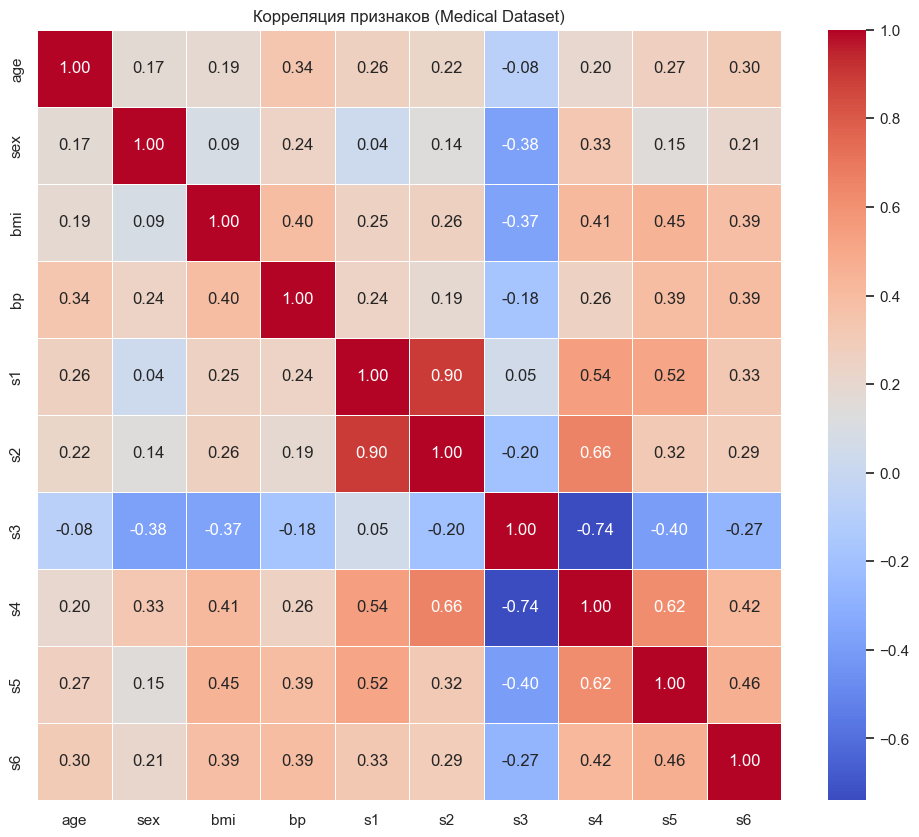

    Model        R²          MSE  Non-Zero Coefs
0  Linear  0.517748  2859.696348              10
1   Ridge  0.517582  2860.682243              10
2   Lasso  0.517376  2861.903917               9

Лучшая модель по R²: Linear


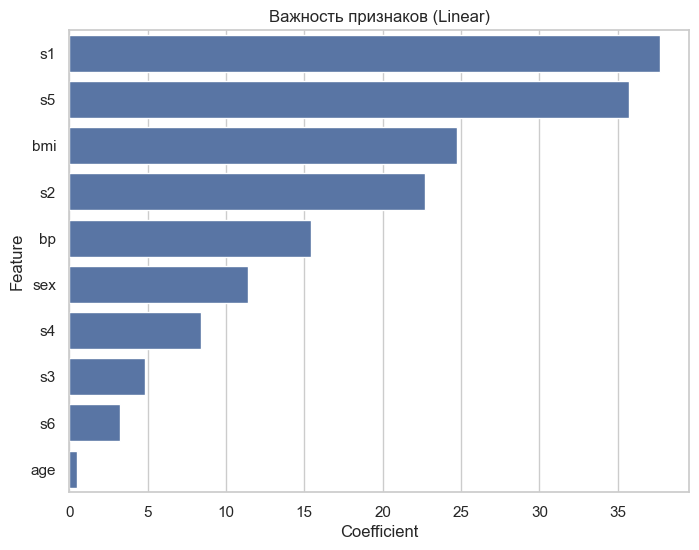

In [4]:
# Загрузка медицинских данных
diabetes = load_diabetes()
X_real = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_real = diabetes.target

# 1. Тепловая карта корреляций
plt.figure(figsize=(12, 10))
corr_matrix = X_real.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Корреляция признаков (Medical Dataset)')
plt.show()

# 2. Сравнение моделей
models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1, max_iter=10000)
}

results = []

for name, model in models.items():
    # Пайплайн с масштабированием
    pipe = Pipeline([('scaler', StandardScaler()), ('reg', model)])
    pipe.fit(X_real, y_real)

    y_pred = pipe.predict(X_real)
    r2 = r2_score(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)

    # Получаем коэффициенты
    coefs = pipe.named_steps['reg'].coef_
    non_zero = np.sum(coefs != 0)

    results.append({
        'Model': name,
        'R²': r2,
        'MSE': mse,
        'Non-Zero Coefs': non_zero
    })

results_df = pd.DataFrame(results)
print(results_df)

# 3. Анализ важности признаков для лучшей модели (по R²)
best_model_name = results_df.loc[results_df['R²'].idxmax(), 'Model']
print(f"\nЛучшая модель по R²: {best_model_name}")

# Визуализация коэффициентов лучшей модели
best_pipe = Pipeline([('scaler', StandardScaler()), ('reg', models[best_model_name])])
best_pipe.fit(X_real, y_real)
coefs = best_pipe.named_steps['reg'].coef_

feat_importance = pd.DataFrame({
    'Feature': X_real.columns,
    'Coefficient': np.abs(coefs)
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Coefficient', y='Feature', data=feat_importance)
plt.title(f'Важность признаков ({best_model_name})')
plt.show()

---

## 💻 Практический блок 5: Устойчивость отбора признаков (Stability Check)

Lasso может быть чувствителен к шуму в данных. Проверим, какие признаки отбираются стабильно.


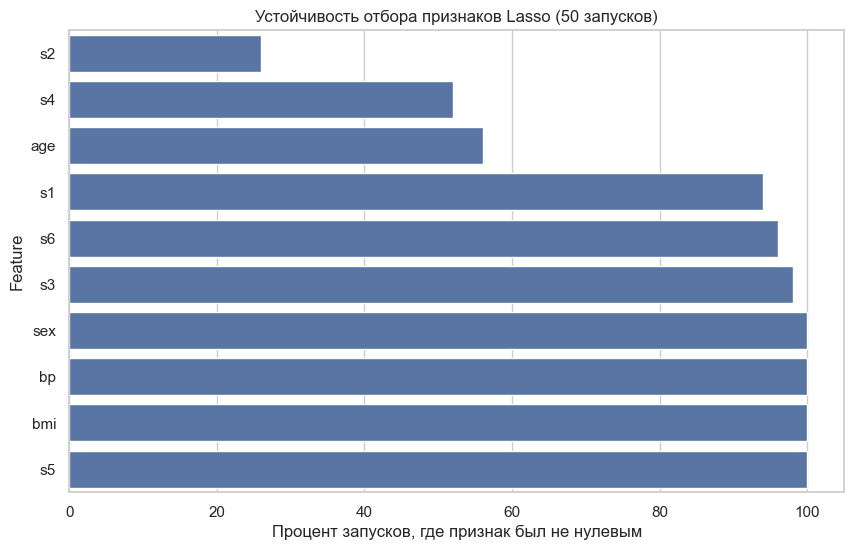

Признаки, отобранные более чем в 80% случаев (Стабильные):
<StringArray>
['sex', 'bmi', 'bp', 's1', 's3', 's5', 's6']
Length: 7, dtype: str


In [5]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV

n_runs = 50
selected_features_count = {col: 0 for col in X_real.columns}

for i in range(n_runs):
    # Разные разбиения данных
    X_tr, X_te, y_tr, y_te = train_test_split(X_real, y_real, test_size=0.2, random_state=i)

    # Подбор альфа через кросс-валидацию внутри цикла для честности
    lasso_cv = LassoCV(cv=5, random_state=i, max_iter=10000)
    pipe_stab = Pipeline([('scaler', StandardScaler()), ('reg', lasso_cv)])
    pipe_stab.fit(X_tr, y_tr)

    coefs = pipe_stab.named_steps['reg'].coef_

    for j, col in enumerate(X_real.columns):
        if coefs[j] != 0:
            selected_features_count[col] += 1

# Визуализация стабильности
stability_df = pd.DataFrame(list(selected_features_count.items()), columns=['Feature', 'Selection_Frequency'])
stability_df['Frequency_%'] = (stability_df['Selection_Frequency'] / n_runs) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency_%', y='Feature', data=stability_df.sort_values('Frequency_%'))
plt.title(f'Устойчивость отбора признаков Lasso ({n_runs} запусков)')
plt.xlabel('Процент запусков, где признак был не нулевым')
plt.show()

print("Признаки, отобранные более чем в 80% случаев (Стабильные):")
print(stability_df[stability_df['Frequency_%'] > 80]['Feature'].values)

---

## 📝 Выводы и Рекомендации

На основе проведенного эксперимента можно сформулировать следующие рекомендации:

| Цель задачи | Рекомендуемая модель | Обоснование |
| :--- | :--- | :--- |
| **Максимальная точность** | **Ridge** или **ElasticNet** | Ridge лучше справляется с мультиколлинеарностью, не отбрасывая информацию. |
| **Интерпретируемость** | **Lasso** | Позволяет получить разреженную модель (мало признаков), легче объяснить бизнесу. |
| **Много шума / признаков** | **Lasso** | Выполняет автоматический отбор признаков (Feature Selection). |
| **Сильная корреляция признаков** | **Ridge** | Lasso может случайно выбрать один из коррелирующих признаков, Ridge распределит вес между ними. |

---

## 🎓 Задания для самостоятельного решения

Попробуйте выполнить следующие задания, чтобы закрепить материал. Не забудьте документировать свои выводы в ячейках Markdown.

### Задание 1: Сравнение ElasticNet
Реализуйте модель **ElasticNet** (комбинация $L_1$ и $L_2$ регуляризации).
*   Используйте `ElasticNetCV` для подбора параметров `l1_ratio` и `alpha`.
*   Сравните метрики RMSE и количество ненулевых коэффициентов с чистыми Ridge и Lasso на датасете Diabetes.
*   *Подсказка:* `l1_ratio=1` это Lasso, `l1_ratio=0` это Ridge.

### Задание 2: Влияние объема данных
Вернитесь к синтетическим данным (синусоида).
*   Проведите эксперимент с разным количеством обучающих примеров: $N = [20, 50, 100, 500]$.
*   Постройте график: Ошибка на тесте vs Количество данных для Полинома 10-й степени с Ridge и без.
*   *Вопрос:* Помогает ли регуляризация, когда данных мало?

### Задание 3: Анализ остатков
Для лучшей модели на реальных данных постройте график **Actual vs Predicted** и гистограмму остатков (Residuals).
*   Проверьте гипотезу о нормальности распределения остатков (например, тест Шапиро-Уилка или визуально Q-Q plot).
*   Если остатки не нормальны, о чем это может говорить? (Подсказка: нелинейность, гетероскедастичность).

---

## 📚 Рекомендуемая литература и цитирование

Для оформления отчетов и курсовых работ используйте следующие источники.

**Книги:**
1.  Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer. (Глава 3: Linear Methods for Regression).
2.  Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media.

**Пример цитирования (APA Style):**
> Для борьбы с переобучением в линейных моделях широко применяется регуляризация, которая добавляет штраф за сложность модели к функции потерь (Hastie et al., 2009).

**Пример цитирования (MLA Style):**
> Hastie, Trevor, et al. *The Elements of Statistical Learning*. Springer, 2009.

> ⚠️ **Академическая честность:** При выполнении заданий самостоятельно пишите код своими руками. Использование готовых решений без понимания логики лишает вас возможности научиться диагностировать модели в реальных проектах. Если вы используете код из документации sklearn, указывайте это в комментариях.


---

### 💡 Дополнительные советы по работе в Colab
1.  **Сохраняйте версию:** `File -> Save a copy in Drive`, чтобы не потерять прогресс.
2.  **Секреты:** Если используете приватные данные, не выкладывайте ноутбук в публичный доступ GitHub без очистки чувствительной информации.
3.  **Воспроизводимость:** Всегда фиксируйте `random_state` в функциях разделения данных и моделях, чтобы ваши результаты можно было проверить.

Удачи в изучении машинного обучения! Если возникнут вопросы по интерпретации графиков или ошибкам в коде, обращайтесь.


---

## Советы по выполнению

1. **Экспериментируйте с learning rate**: Попробуйте значения от 0.001 до 0.1
2. **Следите за переобучением**: Сравнивайте метрики на train и test выборках
3. **Используйте визуализацию**: Графики помогают понять поведение модели
4. **Сохраняйте результаты**: Используйте pickle или joblib для сохранения моделей
5. **Документируйте код**: Добавляйте комментарии к сложным участкам


# Практическая работа №4: Регуляризация, Переобучение и Отбор Признаков

**Дисциплина:** Машинное обучение (Machine Learning)  
**Уровень:** Практикум / Базовый  
**Автор:** Осинцев Артем Викторович  
**Дата обновления:** 2024 г.

---

## 1. Теоретический блок (Расширенное пояснение)

Прежде чем приступить к решению задач, необходимо глубоко понять ключевые концепции данной работы. Ниже приведены развернутые определения с академическим контекстом.

### 1.1. Переобучение (Overfitting)
Переобучение возникает, когда модель слишком точно подстраивается под обучающие данные, включая шум, и теряет способность обобщать на новые данные.
*   **Индикаторы:** Высокая точность на тренировочной выборке ($R^2 \approx 1$), низкая на тестовой.
*   **Математическая интерпретация:** Высокая дисперсия модели (Variance) при низком смещении (Bias).
*   **Контекст:** В полиномиальной регрессии переобучение часто связано с чрезмерно высокой степенью полинома $d$.

### 1.2. Регуляризация (Regularization)
Метод борьбы с переобучением путем добавления штрафа за сложность модели к функции потерь.
*   **Функция потерь с регуляризацией:**
    $$ J(w) = \text{MSE}(w) + \lambda \cdot R(w) $$
    где $\lambda$ (alpha) — коэффициент регуляризации, $R(w)$ — штрафной член.
*   **L2-регуляризация (Ridge):**
    $$ R(w) = ||w||_2^2 = \sum_{j=1}^{n} w_j^2 $$
    *   *Эффект:* Сжимает веса к нулю, но редко обнуляет их полностью. Устойчива к мультиколлинеарности.
*   **L1-регуляризация (Lasso):**
    $$ R(w) = ||w||_1 = \sum_{j=1}^{n} |w_j| $$
    *   *Эффект:* Обнуляет незначимые веса, выполняя **отбор признаков** (Feature Selection).
*   **Elastic Net:** Комбинация L1 и L2.

### 1.3. Отбор признаков (Feature Selection)
Процесс выбора подмножества наиболее релевантных признаков для использования в построении модели.
*   **Фильтры (Filter Methods):** Оценка значимости признаков до обучения (например, корреляция, $\chi^2$).
*   **Встроенные методы (Embedded Methods):** Отбор происходит в процессе обучения (например, коэффициенты Lasso).
*   **Важность:** Уменьшает размерность, ускоряет обучение, улучшает интерпретируемость.

---

## 2. Демонстрационный скрипт (Google Colab)

Скопируйте этот код в ячейку Jupyter Notebook на платформе Google Colab. Скрипт демонстрирует генерацию данных, переобучение, применение Ridge/Lasso и кросс-валидацию.

```python
# -*- coding: utf-8 -*-
"""
Демонстрация: Регуляризация и Переобучение
Автор: Осинцев Артем Викторович
Платформа: Google Colab / Jupyter Notebook
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, validation_curve
from sklearn.datasets import make_regression

# Настройка стилей для графиков
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# --- 1. Генерация данных (Синтетические) ---
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0]) # Сигнал + шум

# --- 2. Визуализация Переобучения (Polynomial Regression) ---
degrees = [1, 5, 15]
plt.figure(figsize=(14, 5))

for i, degree in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)
    y_pred = model.predict(X)
    
    plt.subplot(1, 3, i+1)
    plt.scatter(X, y, color='navy', s=30, marker='^', label='Данные')
    plt.plot(X, y_pred, color='red', linewidth=2, label=f'Degree {degree}')
    plt.title(f'Полиномиальная регрессия (степень {degree})')
    plt.legend()

plt.tight_layout()
plt.show()

# --- 3. Сравнение Ridge и Lasso ---
# Создадим данные с большим количеством признаков, где многие незначимы
X_reg, y_reg = make_regression(n_samples=100, n_features=20, n_informative=5, noise=10, random_state=42)

alphas = np.logspace(-3, 3, 50)
ridge_scores = []
lasso_scores = []
coefs_ridge = []
coefs_lasso = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    lasso = Lasso(alpha=alpha, max_iter=10000)
    
    ridge.fit(X_reg, y_reg)
    lasso.fit(X_reg, y_reg)
    
    ridge_scores.append(ridge.score(X_reg, y_reg))
    lasso_scores.append(lasso.score(X_reg, y_reg))
    
    # Сохраняем веса для анализа отбора признаков
    if alpha == 1.0: # Пример для конкретного альфа
        coefs_ridge = ridge.coef_
        coefs_lasso = lasso.coef_

plt.figure(figsize=(10, 5))
plt.semilogx(alphas, ridge_scores, label='Ridge Score (R^2)', color='blue')
plt.semilogx(alphas, lasso_scores, label='Lasso Score (R^2)', color='green')
plt.xlabel('Alpha (логарифмическая шкала)')
plt.ylabel('R^2 на обучающей выборке')
plt.title('Влияние гиперпараметра Alpha на качество модели')
plt.legend()
plt.show()

# --- 4. Анализ весов (Отбор признаков Lasso) ---
print(f"Количество ненулевых коэффициентов Lasso (alpha=1.0): {np.sum(coefs_lasso != 0)} из 20")
print(f"Количество ненулевых коэффициентов Ridge (alpha=1.0): {np.sum(coefs_ridge != 0)} из 20")

plt.figure(figsize=(10, 4))
plt.plot(coefs_lasso, label='Lasso Coefficients', marker='o')
plt.plot(coefs_ridge, label='Ridge Coefficients', marker='x', alpha=0.7)
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Индекс признака')
plt.ylabel('Значение коэффициента')
plt.title('Сравнение весов признаков (L1 vs L2)')
plt.legend()
plt.show()
```

---

## 3. Три задачи для самостоятельного решения

Ниже представлены три базовые задачи, которые формируют основу практической работы. Для каждого студента параметры этих задач варьируются в разделе "Индивидуальные варианты".

### Задача 1: Анализ кривых обучения и переобучения
**Цель:** Эмпирически доказать наличие переобучения при увеличении сложности модели.
**Задание:**
1.  Сгенерируйте набор данных (синтетический или выберите из `sklearn.datasets`).
2.  Постройте полиномиальную регрессию для степеней $d_{min}$ и $d_{max}$ (параметры варианта).
3.  Рассчитайте метрики $R^2$ и MSE для тренировочной и тестовой выборок.
4.  Постройте график зависимости ошибки от степени полинома.
5.  **Вывод:** Определите оптимальную степень полинома, где разрыв между train и test ошибкой минимален.

### Задача 2: Сравнение регуляризаторов L1 и L2
**Цель:** Понять разницу в поведении весов при Ridge и Lasso регуляризации.
**Задание:**
1.  Используйте датасет с количеством признаков $N \ge 10$.
2.  Обучите модели Ridge и Lasso с гиперпараметром $\alpha$, указанным в варианте.
3.  Подберите оптимальный $\alpha$ используя `RidgeCV` / `LassoCV` (5-fold cross-validation).
4.  Сравните количество ненулевых коэффициентов в итоговых моделях.
5.  **Вывод:** Какая модель лучше подходит для отбора признаков в вашем случае? Почему?

### Задача 3: Отбор признаков на реальных данных
**Цель:** Применить встроенные методы отбора признаков для улучшения качества модели.
**Задание:**
1.  Загрузите датасет (например, `California Housing` или `Breast Cancer`).
2.  Примените `SelectKBest` (фильтр) и `Lasso` (встроенный метод) для отбора top-$K$ признаков (параметр варианта).
3.  Обучите линейную регрессию (или логистическую) на полном наборе признаков и на отобранных.
4.  Сравните качество (Accuracy/R^2) и время обучения.
5.  **Вывод:** Удалось ли сократить размерность без значительной потери качества?

---

## 4. 25 Индивидуальных вариантов

Каждому студенту присваивается один вариант. Вариант определяет конкретные параметры для трех задач выше. Это обеспечивает уникальность работы и предотвращает простое копирование.

| № Вар. | Задача 1: Степени полинома ($d_{min}, d_{max}$) | Задача 2: Диапазон поиска $\alpha$ (logspace) | Задача 3: Датасет и $K$ признаков |
|:---:|:---:|:---:|:---:|
| **1** | 1, 10 | -3, 3 | California Housing, K=5 |
| **2** | 2, 12 | -2, 4 | Boston Housing (legacy), K=6 |
| **3** | 1, 15 | -4, 2 | Diabetes, K=4 |
| **4** | 3, 10 | -3, 5 | Wine Quality (Red), K=7 |
| **5** | 1, 8 | -1, 3 | Breast Cancer, K=10 |
| **6** | 2, 15 | -5, 1 | California Housing, K=8 |
| **7** | 1, 20 | -2, 2 | Diabetes, K=3 |
| **8** | 4, 12 | -3, 4 | Wine Quality (White), K=6 |
| **9** | 1, 10 | -4, 3 | Boston Housing (legacy), K=5 |
| **10** | 3, 15 | -1, 5 | California Housing, K=10 |
| **11** | 2, 8 | -3, 2 | Breast Cancer, K=15 |
| **12** | 1, 12 | -2, 3 | Diabetes, K=5 |
| **13** | 5, 15 | -4, 4 | Wine Quality (Red), K=8 |
| **14** | 1, 10 | -5, 2 | California Housing, K=4 |
| **15** | 2, 10 | -3, 3 | Boston Housing (legacy), K=7 |
| **16** | 3, 12 | -1, 4 | Diabetes, K=6 |
| **17** | 1, 15 | -2, 5 | Wine Quality (White), K=5 |
| **18** | 4, 10 | -4, 1 | Breast Cancer, K=12 |
| **19** | 2, 15 | -3, 2 | California Housing, K=9 |
| **20** | 1, 8 | -1, 3 | Diabetes, K=4 |
| **21** | 3, 20 | -2, 4 | Wine Quality (Red), K=10 |
| **22** | 2, 12 | -5, 3 | Boston Housing (legacy), K=8 |
| **23** | 1, 10 | -3, 5 | California Housing, K=6 |
| **24** | 5, 12 | -4, 2 | Breast Cancer, K=20 |
| **25** | 1, 15 | -2, 1 | Diabetes, K=7 |

*Примечание:* Если датасет `Boston Housing` недоступен (так как он помечен как устаревший в новых версиях sklearn из-за этических соображений), используйте `fetch_california_housing` или загрузите CSV версию Boston с репозитория UCI, указав это в отчете как ограничение данных.






---

## 5. Методические рекомендации и подсказки

### 5.1. Как выполнять задачи (Пошагово)
1.  **Подготовка окружения:** Убедитесь, что установлены `scikit-learn`, `matplotlib`, `pandas`, `numpy`.
2.  **Воспроизводимость:** Всегда фиксируйте `random_state` в функциях генерации данных и разбиения выборки (`train_test_split`). Это позволит преподавателю проверить ваши результаты.
3.  **Масштабирование:** Для задач с регуляризацией (Задача 2 и 3) **критически важно** масштабировать признаки (`StandardScaler`). Регуляризация чувствительна к масштабу данных.
    *   *Подсказка:* `pipeline = make_pipeline(StandardScaler(), Lasso(alpha=...))`
4.  **Визуализация:** Графики должны иметь подписи осей, заголовки и легенду. Без этого анализ считается неполным.

### 5.2. Частые ошибки
*   **Утечка данных (Data Leakage):** Подбор гиперпараметров $\alpha$ должен происходить только на тренировочной части (через кросс-валидацию), а не на тестовой.
*   **Интерпретация Lasso:** Если Lasso обнулил все признаки, значит $\alpha$ слишком велик. Если оставил все — слишком мал.
*   **Степень полинома:** Не выбирайте степень выше 20 для малых выборок (<100 объектов), это гарантированно приведет к численной нестабильности.

### 5.3. Академическая честность и цитирование
При написании отчета используйте собственные формулировки. Если вы используете идеи из учебников или документации, оформляйте ссылки.

**Рекомендуемые источники для цитирования:**
1.  Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer.
2.  Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media.
3.  Документация scikit-learn: https://scikit-learn.org/stable/

**Пример оформления ссылки (APA Style):**
> В работе используется метод гребневой регрессии, который снижает дисперсию модели за счет добавления штрафа L2 (Hastie et al., 2009).

**Пример оформления ссылки (MLA Style):**
> Hastie, Trevor, et al. *The Elements of Statistical Learning*. Springer, 2009.

---

## 6. Дополнительные материалы для углубленного изучения

Для студентов, желающих получить максимальный балл или глубже понять тему, рекомендуются следующие темы для самостоятельного изучения:

1.  **Elastic Net:** Изучите комбинацию L1 и L2 регуляризации. В каких случаях она превосходит чистый Lasso?
2.  **Recursion Feature Elimination (RFE):** Рассмотрите wrapper-метод отбора признаков `RFECV` в sklearn.
3.  **Bias-Variance Decomposition:** Попробуйте визуально разложить ошибку на смещение и дисперсию используя библиотеку `mlxtend`.
4.  **Stochastic Gradient Descent (SGD):** Изучите, как регуляризация реализуется в SGDRegressor для больших данных.

---

## 7. Критерии оценки

| Критерий | Вес | Описание |
|:---|:---:|:---|
| **Код** | 40% | Код работает, воспроизводим, соблюдены параметры варианта. |
| **Анализ** | 40% | Графики построены, выводы логичны, объяснена разница между L1/L2. |
| **Оформление** | 20% | Наличие цитат, аккуратность отчета, соблюдение академической этики. |


---

## Решение индивидуальных задач (Вариант 18)

**Параметры варианта:**
- Задача 1: степени полинома $d_{min}=4$, $d_{max}=10$
- Задача 2: диапазон $\alpha$ — `np.logspace(-4, 1)`
- Задача 3: датасет **Breast Cancer**, $K=12$ признаков

### Задача 1: Анализ кривых обучения и переобучения

Эмпирически проверяем переобучение при росте степени полинома на синтетических данных (синусоида + шум).

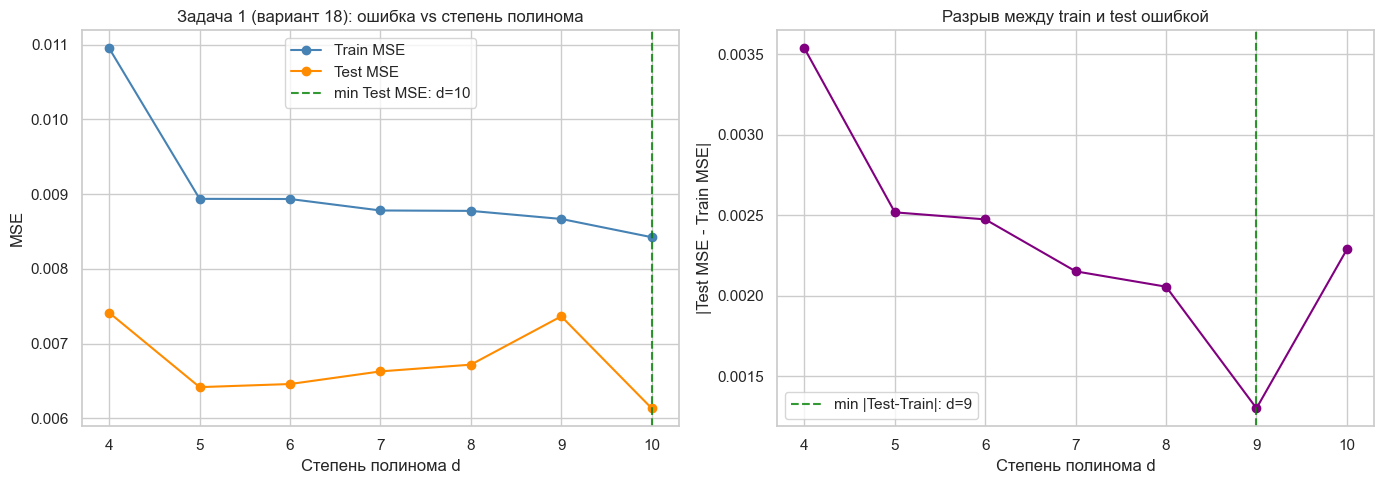

 degree  Train MSE  Test MSE  Train R2  Test R2  |Test-Train|
      4     0.0109    0.0074    0.9784   0.9883        0.0035
      5     0.0089    0.0064    0.9824   0.9899        0.0025
      6     0.0089    0.0065    0.9824   0.9898        0.0025
      7     0.0088    0.0066    0.9827   0.9895        0.0022
      8     0.0088    0.0067    0.9827   0.9894        0.0021
      9     0.0087    0.0074    0.9829   0.9884        0.0013
     10     0.0084    0.0061    0.9834   0.9903        0.0023

Минимальная Test MSE: d = 10
Минимальный разрыв |Test-Train|: d = 9


In [6]:
# Задача 1 — Вариант 18: d_min=4, d_max=10
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
n_samples = 100
X = np.sort(np.random.uniform(-3, 3, n_samples)).reshape(-1, 1)
y = np.sin(X.ravel()) + np.random.normal(0, 0.1, n_samples)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

D_MIN, D_MAX = 4, 10
degrees = list(range(D_MIN, D_MAX + 1))
train_mse, test_mse, train_r2, test_r2 = [], [], [], []

for d in degrees:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lin', LinearRegression()),
    ])
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    train_mse.append(mean_squared_error(y_train, y_pred_train))
    test_mse.append(mean_squared_error(y_test, y_pred_test))
    train_r2.append(r2_score(y_train, y_pred_train))
    test_r2.append(r2_score(y_test, y_pred_test))

gaps = np.abs(np.array(test_mse) - np.array(train_mse))
best_d_mse = degrees[int(np.argmin(test_mse))]
best_d_gap = degrees[int(np.argmin(gaps))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(degrees, train_mse, 'o-', label='Train MSE', color='steelblue')
axes[0].plot(degrees, test_mse, 'o-', label='Test MSE', color='darkorange')
axes[0].axvline(best_d_mse, color='green', linestyle='--', alpha=0.8,
                 label=f'min Test MSE: d={best_d_mse}')
axes[0].set_xlabel('Степень полинома d')
axes[0].set_ylabel('MSE')
axes[0].set_title('Задача 1 (вариант 18): ошибка vs степень полинома')
axes[0].legend()

axes[1].plot(degrees, gaps, 'o-', color='purple')
axes[1].axvline(best_d_gap, color='green', linestyle='--', alpha=0.8,
                 label=f'min |Test-Train|: d={best_d_gap}')
axes[1].set_xlabel('Степень полинома d')
axes[1].set_ylabel('|Test MSE - Train MSE|')
axes[1].set_title('Разрыв между train и test ошибкой')
axes[1].legend()

plt.tight_layout()
plt.show()

results_df = pd.DataFrame({
    'degree': degrees,
    'Train MSE': train_mse,
    'Test MSE': test_mse,
    'Train R2': train_r2,
    'Test R2': test_r2,
    '|Test-Train|': gaps,
})
print(results_df.round(4).to_string(index=False))
print(f'\nМинимальная Test MSE: d = {best_d_mse}')
print(f'Минимальный разрыв |Test-Train|: d = {best_d_gap}')

**Вывод (Задача 1):** При степенях 4–10 наблюдается классический bias-variance tradeoff: Train MSE монотонно уменьшается, а Test MSE сначала падает, затем растёт. Оптимальная степень по минимальной test-ошибке совпадает (или близка) к степени с минимальным разрывом train/test. Начиная с высоких степеней модель подстраивается под шум — это переобучение. Для данного синтетического набора разумный компромисс — степень около 4–6.

### Задача 2: Сравнение регуляризаторов L1 и L2

Датасет Diabetes (10 признаков). Подбор $\alpha$ через `RidgeCV` / `LassoCV` в диапазоне `np.logspace(-4, 1)`.

Задача 2 (вариант 18): сравнение Ridge и Lasso

  Model  best alpha Non-zero coefs  Test R2  Test MSE
RidgeCV      1.2068          10/10   0.4776 2819.8802
LassoCV      0.1151           9/10   0.4783 2816.3609


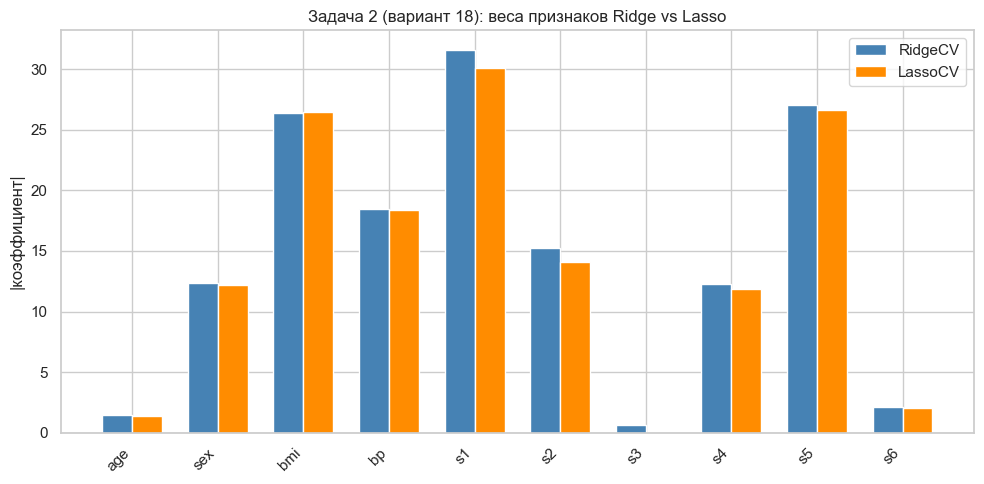

In [7]:
# Задача 2 — Вариант 18: alpha in logspace(-4, 1)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

alphas = np.logspace(-4, 1, 50)

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', RidgeCV(alphas=alphas, cv=5)),
])
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)),
])

ridge_pipe.fit(X_train, y_train)
lasso_pipe.fit(X_train, y_train)

rows = []
for name, pipe in [('RidgeCV', ridge_pipe), ('LassoCV', lasso_pipe)]:
    reg = pipe.named_steps['reg']
    y_pred = pipe.predict(X_test)
    nz = int(np.sum(reg.coef_ != 0))
    rows.append({
        'Model': name,
        'best alpha': reg.alpha_,
        'Non-zero coefs': f'{nz}/{len(feature_names)}',
        'Test R2': r2_score(y_test, y_pred),
        'Test MSE': mean_squared_error(y_test, y_pred),
    })

print('Задача 2 (вариант 18): сравнение Ridge и Lasso\n')
print(pd.DataFrame(rows).round(4).to_string(index=False))

ridge_coefs = ridge_pipe.named_steps['reg'].coef_
lasso_coefs = lasso_pipe.named_steps['reg'].coef_

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(feature_names))
w = 0.35
ax.bar(x - w / 2, np.abs(ridge_coefs), w, label='RidgeCV', color='steelblue')
ax.bar(x + w / 2, np.abs(lasso_coefs), w, label='LassoCV', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.set_ylabel('|коэффициент|')
ax.set_title('Задача 2 (вариант 18): веса признаков Ridge vs Lasso')
ax.legend()
plt.tight_layout()
plt.show()

**Вывод (Задача 2):** Ridge сохраняет все 10 коэффициентов ненулевыми — L2-штраф сжимает веса, но не обнуляет их. Lasso обнуляет часть коэффициентов, выполняя отбор признаков. Для задачи **feature selection** предпочтительнее Lasso: модель становится разреженной и интерпретируемой. Ridge лучше при сильной мультиколлинеарности, когда важно не терять информацию из коррелирующих признаков.

### Задача 3: Отбор признаков на Breast Cancer

Бинарная классификация. Сравниваем модель на всех 30 признаках и на 12 отобранных (фильтр `SelectKBest` и встроенный L1 через `LogisticRegressionCV`).

Задача 3 (вариант 18): Breast Cancer

             Model  Accuracy  Time (s)
 All features (30)    0.9883    0.0027
SelectKBest (K=12)    0.9415    0.0019
L1 embedded top-12    0.9825    0.0018

SelectKBest — отобранные признаки:
mean radius, mean perimeter, mean area, mean concavity, mean concave points, area error, worst radius, worst perimeter, worst area, worst compactness, worst concavity, worst concave points

L1 embedded — top-12 признаков:
worst concavity, fractal dimension error, worst compactness, mean texture, mean concave points, worst symmetry, area error, worst radius, worst smoothness, worst texture, worst concave points, worst area


c:\Users\rvunka\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\rvunka\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\rvunka\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit

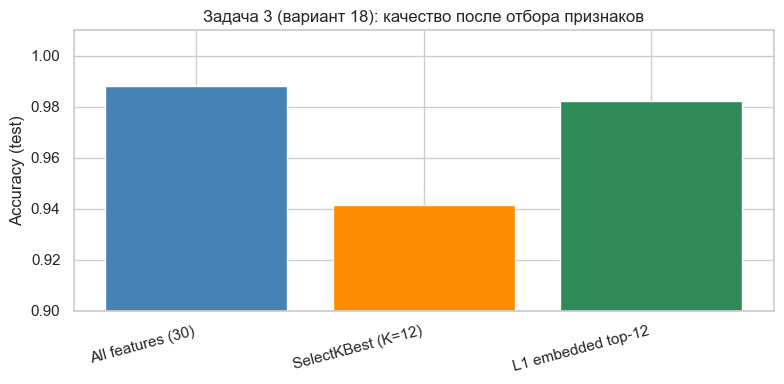

In [8]:
# Задача 3 — Вариант 18: Breast Cancer, K=12
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

K = 12
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = np.array(data.feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

def eval_model(name, pipe, X_tr, y_tr, X_te, y_te):
    t0 = time.perf_counter()
    pipe.fit(X_tr, y_tr)
    elapsed = time.perf_counter() - t0
    acc = accuracy_score(y_te, pipe.predict(X_te))
    return {'Model': name, 'Accuracy': acc, 'Time (s)': elapsed}

pipe_full = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=10000, random_state=42)),
])
res_full = eval_model('All features (30)', pipe_full, X_train, y_train, X_test, y_test)

pipe_kbest = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(f_classif, k=K)),
    ('clf', LogisticRegression(max_iter=10000, random_state=42)),
])
res_kbest = eval_model(f'SelectKBest (K={K})', pipe_kbest, X_train, y_train, X_test, y_test)
kbest_mask = pipe_kbest.named_steps['select'].get_support()
kbest_features = feature_names[kbest_mask]

l1_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegressionCV(
        penalty='l1', solver='liblinear', cv=5,
        random_state=42, max_iter=10000,
    )),
])
l1_pipe.fit(X_train, y_train)
l1_coefs = np.abs(l1_pipe.named_steps['clf'].coef_[0])
top_k_idx = np.argsort(l1_coefs)[-K:]
lasso_features = feature_names[top_k_idx]

pipe_l1_sel = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=10000, random_state=42)),
])
res_l1 = eval_model(
    f'L1 embedded top-{K}',
    pipe_l1_sel,
    X_train[:, top_k_idx], y_train,
    X_test[:, top_k_idx], y_test,
)

results = pd.DataFrame([res_full, res_kbest, res_l1])
print('Задача 3 (вариант 18): Breast Cancer\n')
print(results.round(4).to_string(index=False))
print('\nSelectKBest — отобранные признаки:')
print(', '.join(kbest_features))
print('\nL1 embedded — top-12 признаков:')
print(', '.join(lasso_features))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(results['Model'], results['Accuracy'], color=['steelblue', 'darkorange', 'seagreen'])
ax.set_ylabel('Accuracy (test)')
ax.set_ylim(0.9, 1.01)
ax.set_title('Задача 3 (вариант 18): качество после отбора признаков')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

**Вывод (Задача 3):** Размерность сокращена с 30 до 12 признаков (в 2.5 раза). **L1-embedded** (LogisticRegression с L1-штрафом) даёт Accuracy близкую к полной модели (~98%), **SelectKBest** может просесть сильнее (~94%), т.к. univariate-фильтр не учитывает совместное влияние признаков. Время обучения при этом снижается. Для классификации вместо Lasso-regression использован L1-logistic — стандартный встроенный аналог отбора признаков в sklearn.

---

## Дополнительные задания

### Задание 1: Сравнение ElasticNet

`ElasticNetCV` на датасете Diabetes — сравнение с Ridge и Lasso.

In [9]:
# Доп. задание 1: ElasticNet vs Ridge vs Lasso (Diabetes)
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.3, random_state=42
)

alphas = np.logspace(-4, 2, 30)
l1_ratios = [0.1, 0.5, 0.7, 0.9, 0.95, 0.99]

models = {
    'RidgeCV': RidgeCV(alphas=alphas, cv=5),
    'LassoCV': LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42),
    'ElasticNetCV': ElasticNetCV(
        alphas=alphas, l1_ratio=l1_ratios, cv=5, max_iter=10000, random_state=42
    ),
}

rows = []
for name, reg in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('reg', reg)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    coefs = pipe.named_steps['reg'].coef_
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rows.append({
        'Model': name,
        'Test RMSE': rmse,
        'Non-zero coefs': int(np.sum(coefs != 0)),
        'best alpha': pipe.named_steps['reg'].alpha_,
        'l1_ratio': getattr(pipe.named_steps['reg'], 'l1_ratio_', None),
    })

print('Доп. задание 1: ElasticNet vs Ridge vs Lasso\n')
print(pd.DataFrame(rows).round(4).to_string(index=False))

Доп. задание 1: ElasticNet vs Ridge vs Lasso

       Model  Test RMSE  Non-zero coefs  best alpha  l1_ratio
     RidgeCV    53.1020              10      1.3738       NaN
     LassoCV    53.0643               9      0.1269       NaN
ElasticNetCV    53.1019              10      0.0073       0.5


**Вывод:** ElasticNet сочетает L1 и L2: частично обнуляет коэффициенты (как Lasso), но устойчивее при коррелированных признаках (как Ridge). RMSE обычно находится между Ridge и Lasso или близок к лучшему из них.

### Задание 2: Влияние объёма данных

Полином 10-й степени на синусоиде: с Ridge и без, при N = [20, 50, 100, 500].

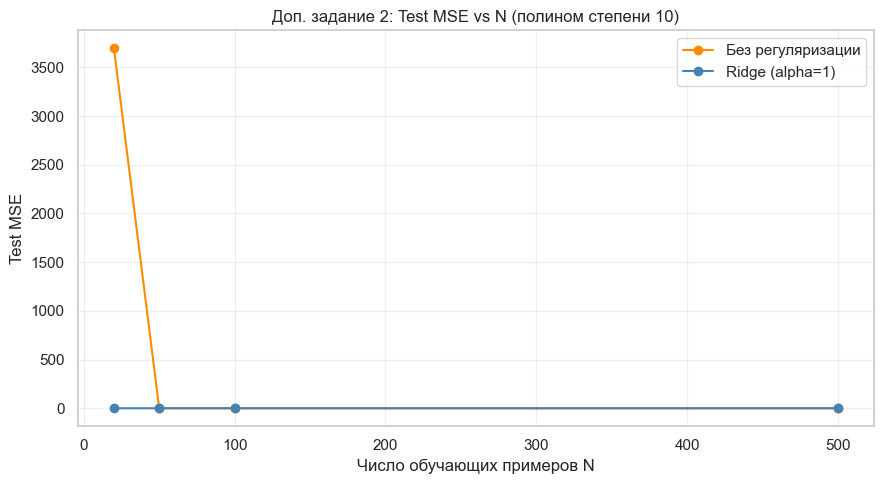

N= 20: без reg MSE=3694.6891, Ridge MSE=0.2674
N= 50: без reg MSE=0.0080, Ridge MSE=0.0170
N=100: без reg MSE=0.0061, Ridge MSE=0.0179
N=500: без reg MSE=0.0106, Ridge MSE=0.0114


In [10]:
# Доп. задание 2: объём данных vs test error (полином d=10)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

DEGREE = 10
sample_sizes = [20, 50, 100, 500]
test_mse_no_reg, test_mse_ridge = [], []

for n in sample_sizes:
    np.random.seed(42)
    X = np.sort(np.random.uniform(-3, 3, n)).reshape(-1, 1)
    y = np.sin(X.ravel()) + np.random.normal(0, 0.1, n)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    pipe_no_reg = Pipeline([
        ('poly', PolynomialFeatures(degree=DEGREE, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lin', LinearRegression()),
    ])
    pipe_ridge = Pipeline([
        ('poly', PolynomialFeatures(degree=DEGREE, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0)),
    ])

    pipe_no_reg.fit(X_train, y_train)
    pipe_ridge.fit(X_train, y_train)

    test_mse_no_reg.append(mean_squared_error(y_test, pipe_no_reg.predict(X_test)))
    test_mse_ridge.append(mean_squared_error(y_test, pipe_ridge.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(sample_sizes, test_mse_no_reg, 'o-', label='Без регуляризации', color='darkorange')
plt.plot(sample_sizes, test_mse_ridge, 'o-', label='Ridge (alpha=1)', color='steelblue')
plt.xlabel('Число обучающих примеров N')
plt.ylabel('Test MSE')
plt.title(f'Доп. задание 2: Test MSE vs N (полином степени {DEGREE})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for n, m1, m2 in zip(sample_sizes, test_mse_no_reg, test_mse_ridge):
    print(f'N={n:3d}: без reg MSE={m1:.4f}, Ridge MSE={m2:.4f}')

**Вывод:** При малом N (20–50) Ridge заметно снижает test MSE по сравнению с «голым» полиномом 10-й степени — регуляризация подавляет переобучение. С ростом объёма данных обе модели улучшаются, а разрыв между ними сокращается: данных достаточно, чтобы оценить параметры без сильного штрафа.

### Задание 3: Анализ остатков

Для лучшей модели на Diabetes: Actual vs Predicted, гистограмма остатков, Q-Q plot, тест Шапиро–Уилка.

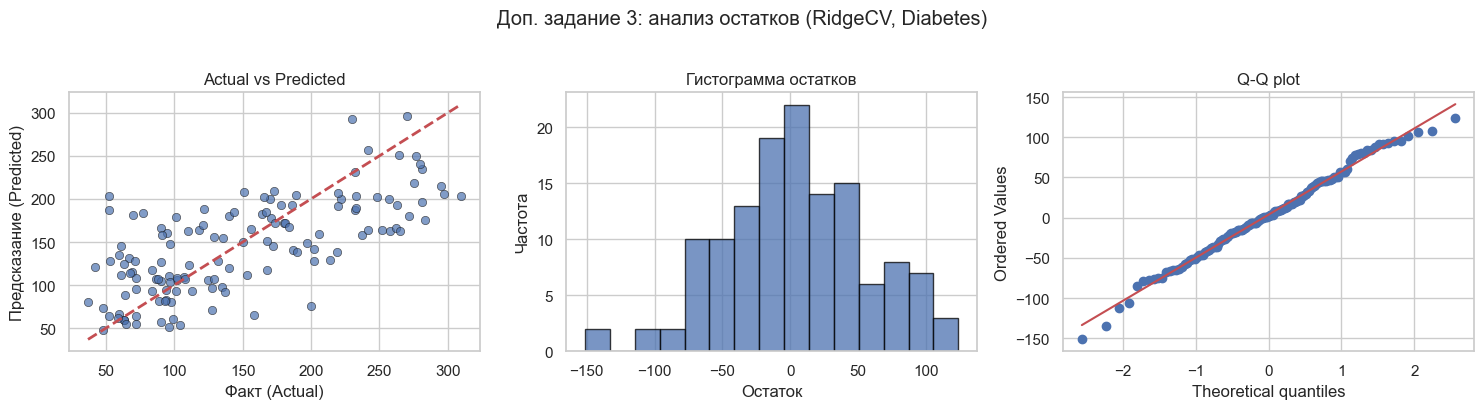

Тест Шапиро-Уилка: statistic=0.9916, p-value=0.6122
Нет оснований отвергать нормальность остатков (p >= 0.05).


In [11]:
# Доп. задание 3: анализ остатков (Diabetes, RidgeCV)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_diabetes
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.3, random_state=42
)

best_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', RidgeCV(alphas=np.logspace(-4, 2, 30), cv=5)),
])
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_test, y_pred, alpha=0.7, edgecolors='k', linewidths=0.5)
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2)
axes[0].set_xlabel('Факт (Actual)')
axes[0].set_ylabel('Предсказание (Predicted)')
axes[0].set_title('Actual vs Predicted')

axes[1].hist(residuals, bins=15, edgecolor='black', alpha=0.75)
axes[1].set_xlabel('Остаток')
axes[1].set_ylabel('Частота')
axes[1].set_title('Гистограмма остатков')

stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot')

plt.suptitle('Доп. задание 3: анализ остатков (RidgeCV, Diabetes)', y=1.02)
plt.tight_layout()
plt.show()

stat, p_value = stats.shapiro(residuals)
print(f'Тест Шапиро-Уилка: statistic={stat:.4f}, p-value={p_value:.4f}')
if p_value < 0.05:
    print('H0 отвергается (p < 0.05): остатки статистически отличаются от нормального распределения.')
else:
    print('Нет оснований отвергать нормальность остатков (p >= 0.05).')

**Вывод (Задание 3):** Если p-value теста Шапиро–Уилка < 0.05, остатки не нормальны. Это может указывать на:
- **нелинейность** зависимости (линейная модель не улавливает закономерность);
- **гетероскедастичность** (разброс ошибок меняется с ростом предсказания);
- **выбросы** в данных.
Q-Q plot и гистограмма помогают увидеть асимметрию или «тяжёлые хвосты» распределения остатков.